In [5]:
import pandas as pd

df = pd.read_csv("Newzeland.csv", sep=';')

# Show quick info
print("Number of columns:", len(df.columns))
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

Number of columns: 3

Column names: ['Category', 'line', 'OECD_Average']

Data types:
 Category        float64
line             object
OECD_Average     object
dtype: object


In [6]:
df.head()

,Category,line,OECD_Average
0,2000.00,"528,79974","499,53403"
1,2000.50,"527,59167","499,181"
2,2000.50,NaN,NaN
3,2000.25,"528,19574","499,35751"
4,2000.25,NaN,NaN


In [8]:
# Convert columns to float
df["line"] = pd.to_numeric(df["line"].str.replace(',', '.').str.strip(), errors='coerce')
df["OECD_Average"] = pd.to_numeric(df["OECD_Average"].str.replace(',', '.').str.strip(), errors='coerce')

In [9]:
print("\nData types:\n", df.dtypes)


Data types:
 Category        float64
line            float64
OECD_Average    float64
dtype: object


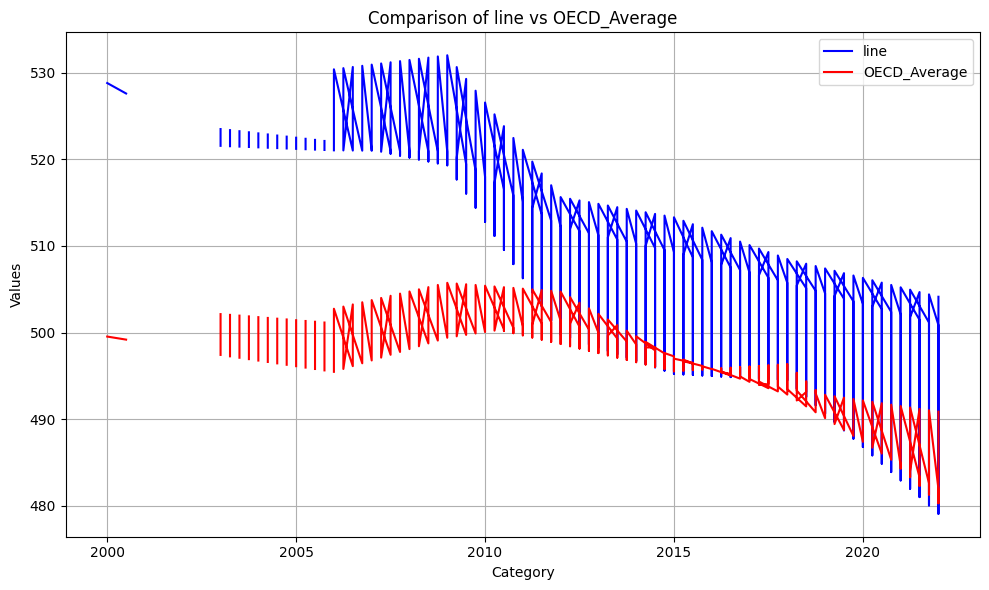

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df["Category"], df["line"], color="blue", label="line")
plt.plot(df["Category"], df["OECD_Average"], color="red", label="OECD_Average")

plt.xlabel("Category")
plt.ylabel("Values")
plt.title("Comparison of line vs OECD_Average")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

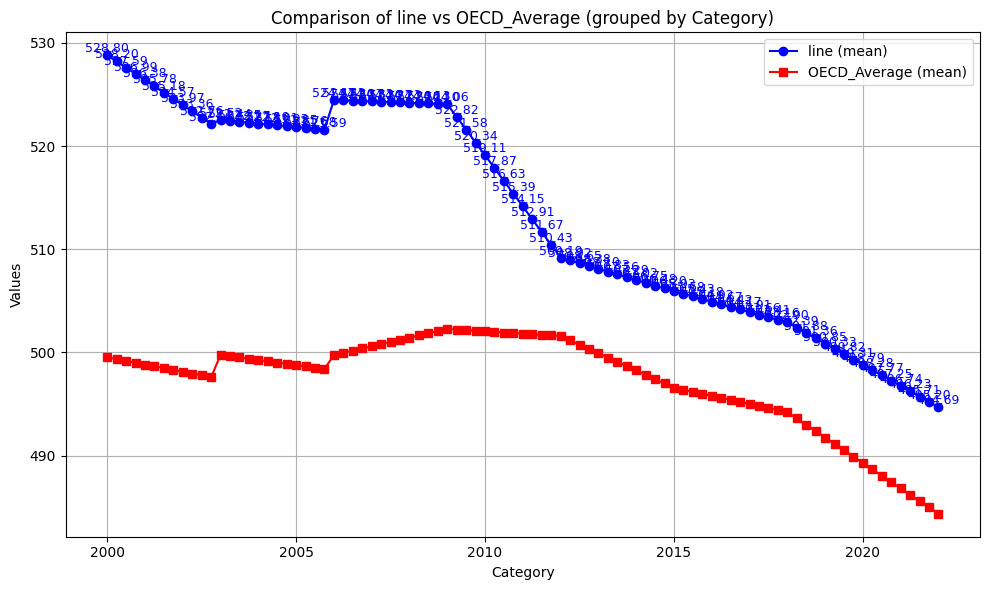

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by Category to handle repeated occurrences
grouped = df.groupby("Category", as_index=False).agg({
    "line": "mean",
    "OECD_Average": "mean"
})

plt.figure(figsize=(10, 6))
plt.plot(grouped["Category"], grouped["line"], color="blue", marker='o', label="line (mean)")
plt.plot(grouped["Category"], grouped["OECD_Average"], color="red", marker='s', label="OECD_Average (mean)")

# Add value labels for the blue line data points
for i, val in enumerate(grouped["line"]):
    plt.text(grouped["Category"].iloc[i], val, f"{val:.2f}", color="blue", fontsize=9, ha='center', va='bottom')

plt.xlabel("Category")
plt.ylabel("Values")
plt.title("Comparison of line vs OECD_Average (grouped by Category)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


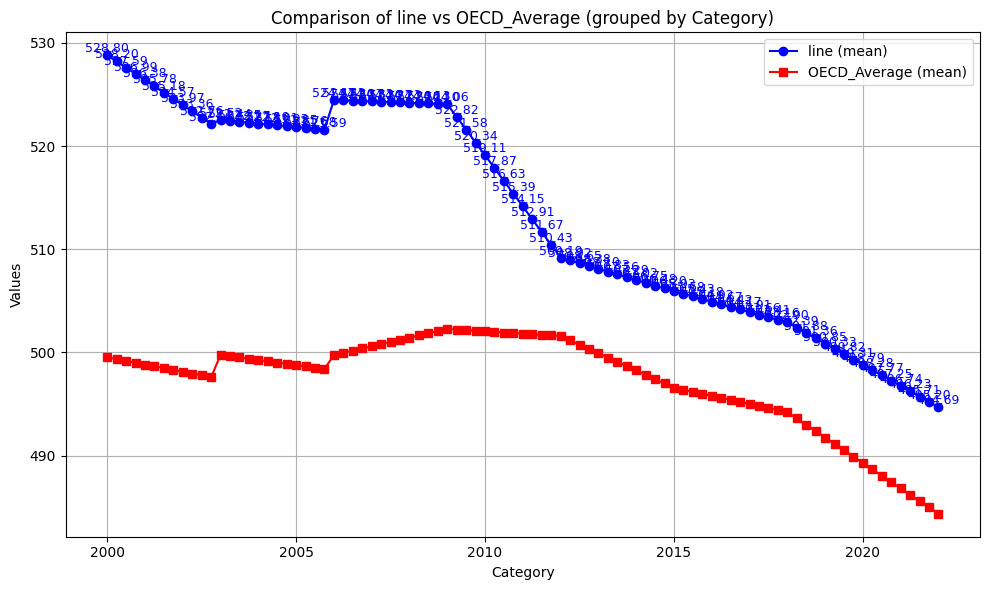

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# collapse any repeated Category entries
grouped = df.groupby("Category", as_index=False).mean(numeric_only=True)

plt.figure(figsize=(10, 6))
plt.plot(grouped["Category"], grouped["line"], color="blue", marker="o", label="line (mean)")
plt.plot(grouped["Category"], grouped["OECD_Average"], color="red", marker="s", label="OECD_Average (mean)")

# label each blue point with its numeric value
for i, v in enumerate(grouped["line"]):
    plt.text(grouped["Category"].iloc[i], v, f"{v:.2f}",
             color="blue", fontsize=9, ha="center", va="bottom")

plt.xlabel("Category")
plt.ylabel("Values")
plt.title("Comparison of line vs OECD_Average (grouped by Category)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
